In [2]:
#######################################
####  XGBOOST | 2018-2023 Level-F  ####
#######################################
import xgboost as xgb
from xgboost import XGBClassifier
import shap
import re
from collections import defaultdict
import pyreadstat
import pandas as pd
import pickle
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/opt/anaconda3/envs/london/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open('years_levels_data.pkl', 'rb') as f:
    year_dfs = pickle.load(f)

In [4]:
frames = []
for year in sorted(year_dfs.keys()):
    if year < 2018:
        continue
    df = year_dfs[year]['F'].copy()
    df['year'] = year
    frames.append(df)

df_combined = pd.concat(frames, ignore_index=True)
drop_cols = ['Relig7', 'Orient4', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'motive_POP', 'LondInOut']
df_combined = df_combined.drop(columns=drop_cols, errors='ignore')
print(df_combined.shape)

(55912, 55)


In [5]:
df_combined.isnull().sum()[df_combined.isnull().sum() > 0]

wt_time                       229
happy                       35323
lifesat                     35314
worthw                      35367
anxious                     35338
Motiva_POP                    873
motivb_POP                    766
motivc_POP                   1223
motivd_POP                   2005
VolAny                      12248
VolCnt                      12248
volint1                     12248
volint2                     12248
volint3                     12248
volint4                     12248
volint5                     12248
volint6                     12248
volint7                     12248
Disab3                       3201
Gend3                          60
Age9                          353
Eth7                         2986
NSSEC5                       3049
Educ6                        3954
MEMS7_IN_SPORTCOUNT_A01     35067
MEMS7_OUT_SPORTCOUNT_A01    35067
VolFrqB_Pop                 20111
dtype: int64

In [6]:
exclude_from_pca = [
    'MEMS7GR_ALL',
    'wt_final', 'wt_time', 'xStrata', 
    'Reg9', 'LA_2023',
    'happy', 'lifesat', 'worthw', 'anxious',
    'DURATION_SPORTCOUNT_A01',
    'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'year'
]
pca_cols = [c for c in df_combined.columns if c not in exclude_from_pca]

In [7]:
vol_cols = ['VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7']
vol_cols = [c for c in vol_cols if c in df_combined.columns]
df_combined[vol_cols] = df_combined[vol_cols].fillna(0)

In [8]:
df_encoded = pd.get_dummies(df_combined[pca_cols], columns=['Disab3', 'Gend3', 'Eth7'])

In [9]:
df_encoded = df_encoded.fillna(df_encoded.median())
df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0]

Series([], dtype: int64)

In [10]:
y = (df_combined['MEMS7GR_ALL'] == 2).astype(int)

In [11]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
xgb_model.fit(df_encoded, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

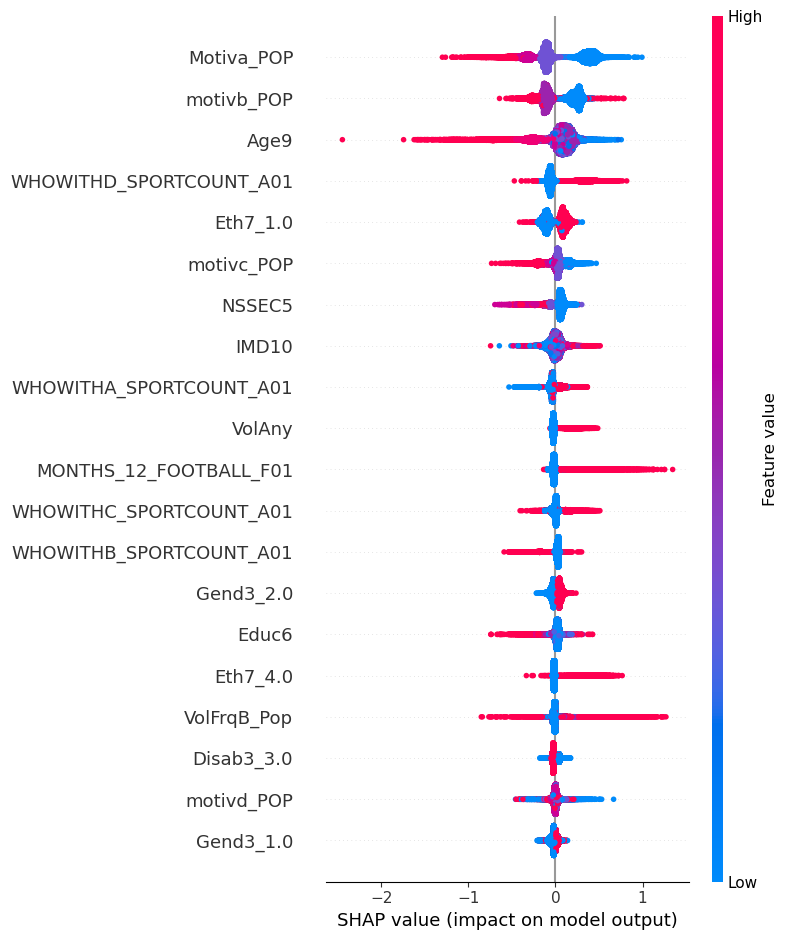

In [12]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_encoded)
shap.summary_plot(shap_values, df_encoded)

In [13]:
df_disabled = df_combined[df_combined['Disab3'] <= 2]
df_disadvantaged = df_combined[df_combined['IMD10'] <= 3]

In [14]:
idx_disabled = df_disabled.index
X_disabled = df_encoded.loc[idx_disabled]
y_disabled = (df_disabled['MEMS7GR_ALL'] == 2).astype(int)

In [15]:
idx_disadvantaged = df_disadvantaged.index
X_disadvantaged = df_encoded.loc[idx_disadvantaged]
y_disadvantaged = (df_disadvantaged['MEMS7GR_ALL'] == 2).astype(int)

In [16]:
xgb_disadvantaged = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
xgb_disadvantaged.fit(X_disadvantaged, y_disadvantaged)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
xgb_disabled = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
xgb_disabled.fit(X_disabled, y_disabled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
explainer = shap.TreeExplainer(xgb_disabled)
shap_values = explainer.shap_values(X_disabled)

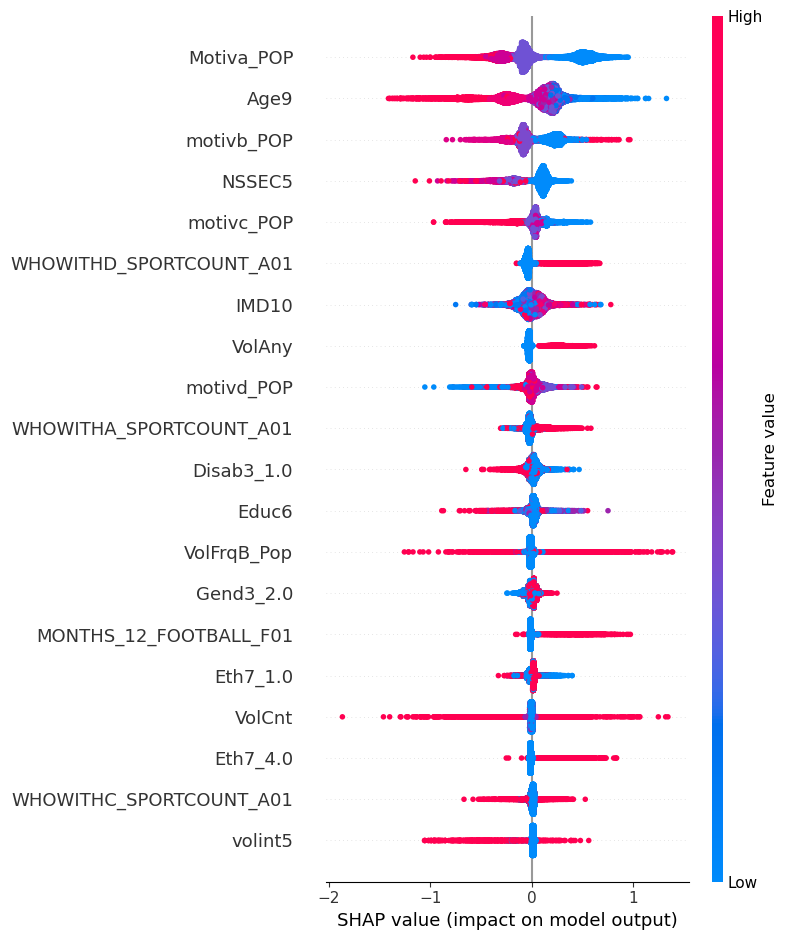

In [19]:
shap.summary_plot(shap_values, X_disabled)

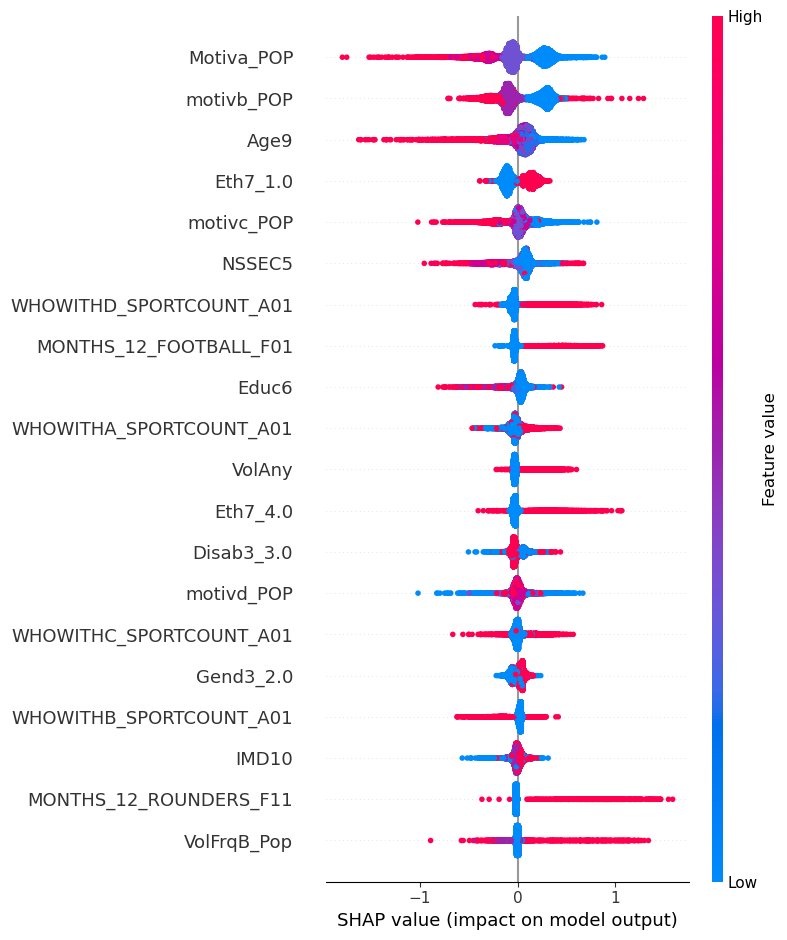

In [20]:
explainer = shap.TreeExplainer(xgb_disadvantaged)
shap_values = explainer.shap_values(X_disadvantaged)
shap.summary_plot(shap_values, X_disadvantaged)

In [21]:
# Older adults (Age9 >= 7)
df_older = df_combined[df_combined['Age9'] >= 7]
idx_older = df_older.index
X_older = df_encoded.loc[idx_older]
y_older = (df_older['MEMS7GR_ALL'] == 2).astype(int)

# Ethnic minorities (Eth7 != 1, non-White British)
df_ethnic = df_combined[df_combined['Eth7'] != 1]
idx_ethnic = df_ethnic.index
X_ethnic = df_encoded.loc[idx_ethnic]
y_ethnic = (df_ethnic['MEMS7GR_ALL'] == 2).astype(int)

# Disabled + disadvantaged intersection
df_intersect = df_combined[(df_combined['Disab3'] <= 2) & (df_combined['IMD10'] <= 3)]
idx_intersect = df_intersect.index
X_intersect = df_encoded.loc[idx_intersect]
y_intersect = (df_intersect['MEMS7GR_ALL'] == 2).astype(int)

# Check sizes before running
print(f"Older: {len(df_older)}, Ethnic minorities: {len(df_ethnic)}, Intersection: {len(df_intersect)}")

Older: 9651, Ethnic minorities: 25896, Intersection: 4689



--- older ---


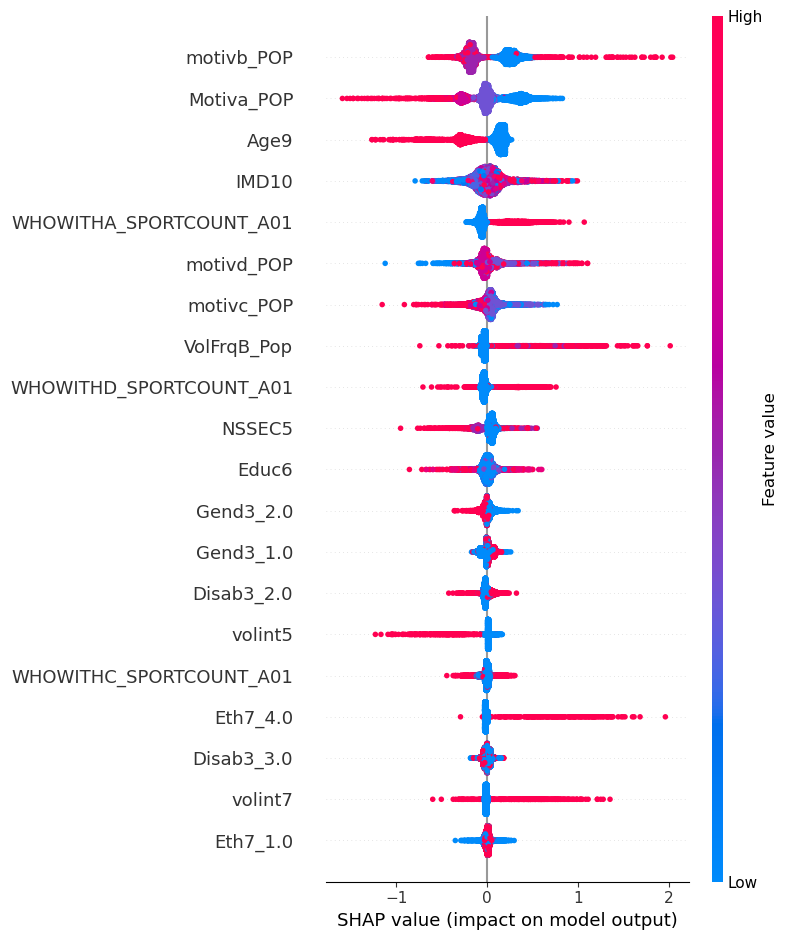


--- ethnic ---


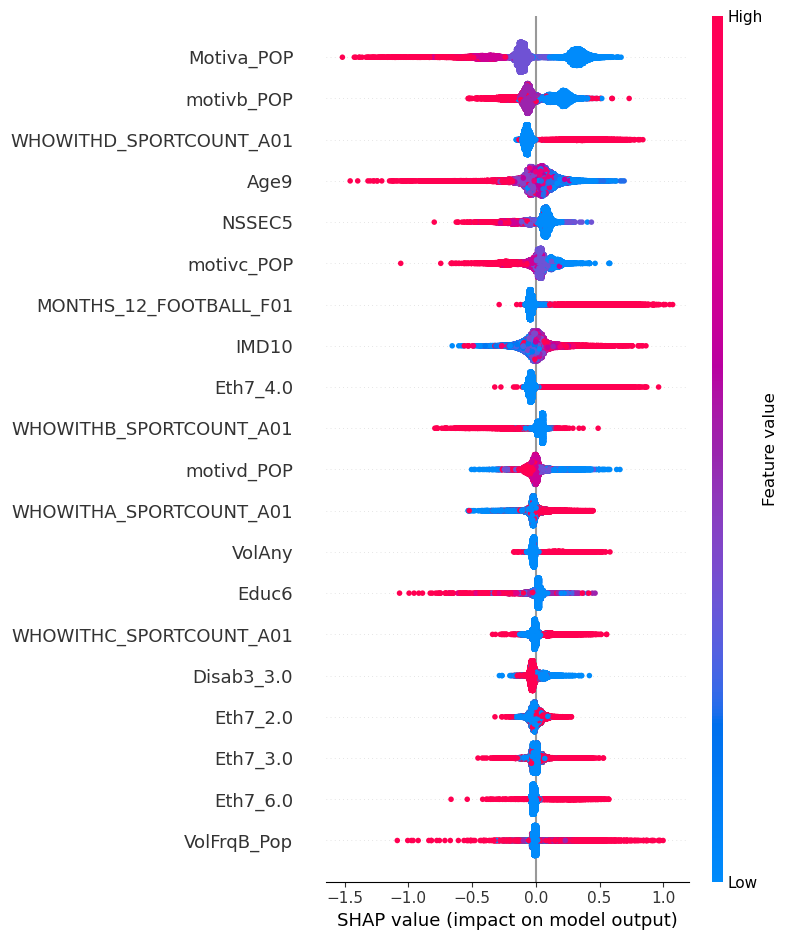


--- intersect ---


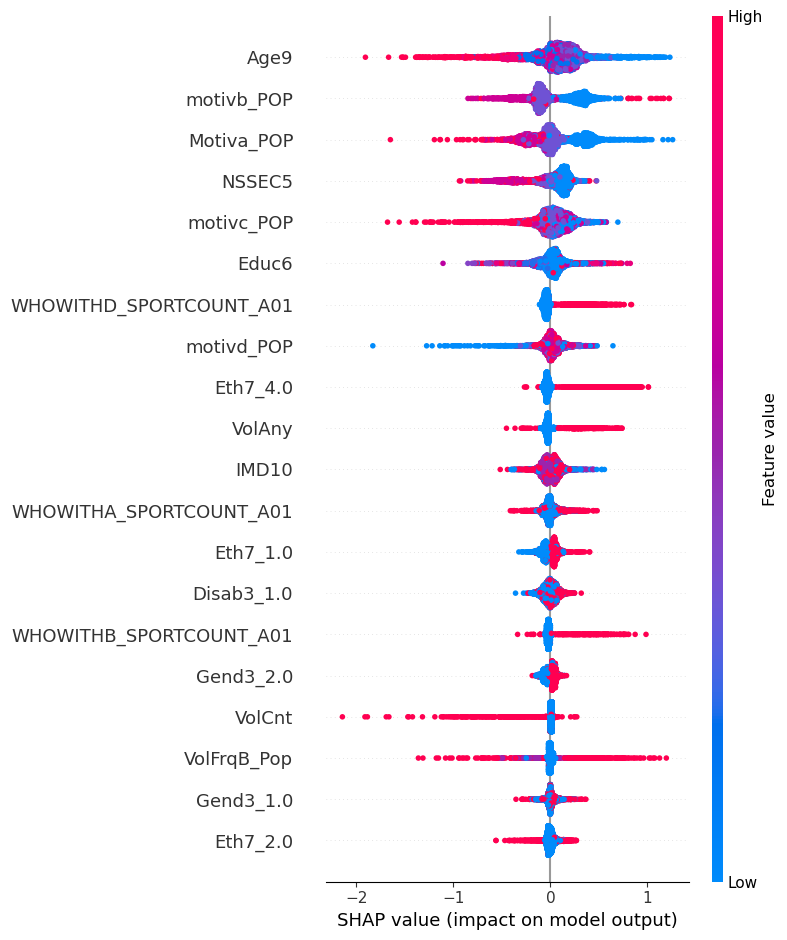

In [22]:
for label, X_sub, y_sub in [
    ('older', X_older, y_older),
    ('ethnic', X_ethnic, y_ethnic),
    ('intersect', X_intersect, y_intersect)
]:
    xgb = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
    xgb.fit(X_sub, y_sub)
    explainer = shap.TreeExplainer(xgb)
    shap_vals = explainer.shap_values(X_sub)
    print(f"\n--- {label} ---")
    shap.summary_plot(shap_vals, X_sub)

In [23]:
df_women = df_combined[df_combined['Gend3'] == 2]
idx_women = df_women.index
X_female = df_encoded.loc[idx_women]
y_female = (df_women['MEMS7GR_ALL'] == 2).astype(int)

print(f"Women: {len(df_women)}")

Women: 30284


In [24]:
xgb_female = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
xgb_female.fit(X_female, y_female)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

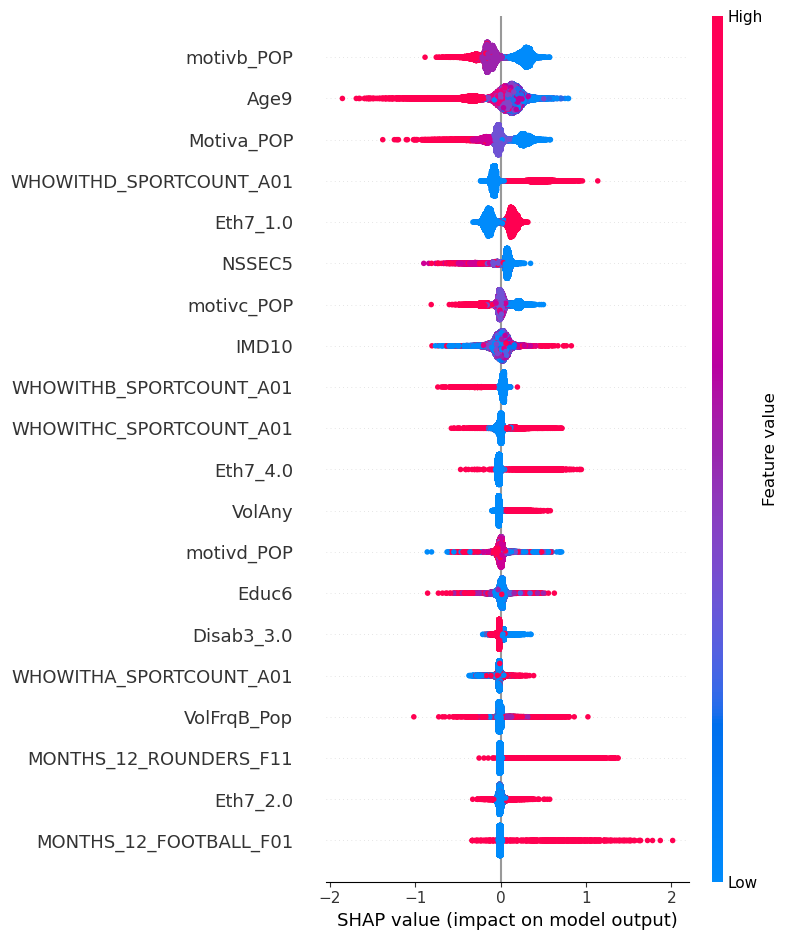

In [25]:
explainer = shap.TreeExplainer(xgb_female)
shap_values = explainer.shap_values(X_female)
shap.summary_plot(shap_values, X_female)

In [26]:
"""
Motivation
- `Motiva_POP` — "I find sport enjoyable and satisfying"
- `motivb_POP` — "It's important to me to do sport regularly"
- `motivc_POP` — "I feel guilty when I don't do sport"
- `motivd_POP` — "I do sport because I don't want to disappoint other people"

Demographics
- `Age9` — age in 9 bands (1=16-24 up to 9=75+)
- `NSSEC5` — socioeconomic class (1=higher managerial to 5=routine/manual)
- `IMD10` — deprivation decile (1=most deprived, 10=least deprived)
- `Educ6` — highest education level (6 bands)

Ethnicity (one-hot)
- `Eth7_1.0` — White British
- `Eth7_2.0` — White Other
- `Eth7_4.0` — Asian/Asian British

Disability (one-hot)
- `Disab3_1.0` — limiting disability
- `Disab3_2.0` — non-limiting disability
- `Disab3_3.0` — no disability

Gender (one-hot)
- `Gend3_1.0` — Male
- `Gend3_2.0` — Female

Who you sport with
- `WHOWITHA` — alone
- `WHOWITHB` — with household members
- `WHOWITHC` — with friends/family outside household
- `WHOWITHD` — with a club or organised group

Volunteering
- `VolAny` — any volunteering (binary)
- `VolFrqB_Pop` — volunteering frequency
- `VolCnt` — number of volunteering roles
- `volint5` — volunteer role type (specific role 5)

Sport participation
- `MONTHS_12_FOOTBALL_F01` — played football in last 12 months
- `MONTHS_12_ROUNDERS_F11` — played rounders (likely sparse artefact, treat with caution)
"""

'\nMotivation\n- `Motiva_POP` — "I find sport enjoyable and satisfying"\n- `motivb_POP` — "It\'s important to me to do sport regularly"\n- `motivc_POP` — "I feel guilty when I don\'t do sport"\n- `motivd_POP` — "I do sport because I don\'t want to disappoint other people"\n\nDemographics\n- `Age9` — age in 9 bands (1=16-24 up to 9=75+)\n- `NSSEC5` — socioeconomic class (1=higher managerial to 5=routine/manual)\n- `IMD10` — deprivation decile (1=most deprived, 10=least deprived)\n- `Educ6` — highest education level (6 bands)\n\nEthnicity (one-hot)\n- `Eth7_1.0` — White British\n- `Eth7_2.0` — White Other\n- `Eth7_4.0` — Asian/Asian British\n\nDisability (one-hot)\n- `Disab3_1.0` — limiting disability\n- `Disab3_2.0` — non-limiting disability\n- `Disab3_3.0` — no disability\n\nGender (one-hot)\n- `Gend3_1.0` — Male\n- `Gend3_2.0` — Female\n\nWho you sport with\n- `WHOWITHA` — alone\n- `WHOWITHB` — with household members\n- `WHOWITHC` — with friends/family outside household\n- `WHOWITHD` 

In [48]:
results = {}

for label, X_sub, y_sub in [
    ('overall', df_encoded, y),
    ('disabled', X_disabled, y_disabled),
    ('disadvantaged', X_disadvantaged, y_disadvantaged),
    ('disabled+deprived', X_intersect, y_intersect),
    ('older', X_older, y_older),
    ('ethnic', X_ethnic, y_ethnic),
    ('women', X_female, y_female),
]:
    xgb = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
    xgb.fit(X_sub, y_sub)
    explainer = shap.TreeExplainer(xgb)
    shap_vals = explainer.shap_values(X_sub)
    mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=X_sub.columns)
    results[label] = mean_abs_shap.sort_values(ascending=False).head(7)

comparison = pd.DataFrame(results)
print(comparison)

                          overall  disabled  disadvantaged  disabled+deprived  \
Age9                     0.162347  0.255711       0.135630           0.236084   
Educ6                         NaN       NaN            NaN           0.099294   
Eth7_1.0                 0.102182       NaN       0.117304                NaN   
IMD10                         NaN  0.088080            NaN                NaN   
MONTHS_12_FOOTBALL_F01        NaN       NaN            NaN                NaN   
Motiva_POP               0.275387  0.288407       0.209816           0.196055   
NSSEC5                   0.085663  0.146747       0.108452           0.155418   
WHOWITHA_SPORTCOUNT_A01       NaN       NaN            NaN                NaN   
WHOWITHD_SPORTCOUNT_A01  0.115734  0.091960       0.085951           0.089810   
motivb_POP               0.177978  0.155970       0.195377           0.209018   
motivc_POP               0.086491  0.096210       0.109355           0.142264   
motivd_POP                  

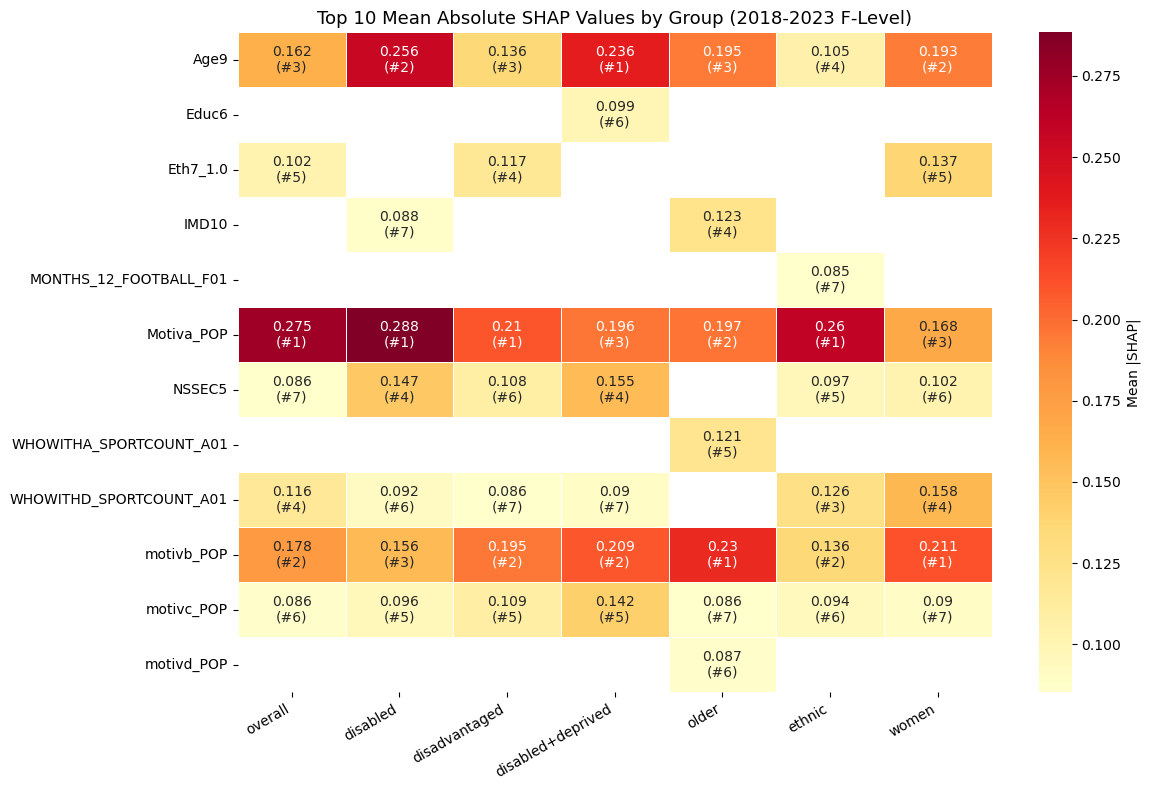

In [49]:
ranks = comparison.rank(ascending=False, method='min', na_option='bottom').astype('Int64')
annot = comparison.round(3).astype(str) + '\n(#' + ranks.astype(str) + ')'

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    comparison,
    annot=annot,
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Mean |SHAP|'}
)

ax.set_title('Top 10 Mean Absolute SHAP Values by Group (2018-2023 F-Level)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Motivation**
- `Motiva_POP` — "I find sport enjoyable and satisfying" (intrinsic enjoyment)
- `motivb_POP` — "It's important to me to do sport regularly" (identity/habit)
- `motivc_POP` — "I feel guilty when I don't do sport" (internalised obligation)
- `motivd_POP` — "I do sport because I don't want to disappoint other people" (social/extrinsic)

**Demographics**
- `Age9` — age in 9 bands (1=16-24, 9=75+)
- `Educ6` — highest education level (6 bands, 1=no quals, 6=degree+)
- `NSSEC5` — occupational class (1=higher managerial, 5=routine/manual)
- `IMD10` — deprivation decile (1=most deprived, 10=least deprived)

**Ethnicity (one-hot from Eth7)**
- `Eth7_1.0` — White British
- `Eth7_4.0` — Black

**Disability (one-hot from Disab3)**
- `Disab3_1.0` — limiting disability
- `Disab3_2.0` — non-limiting disability
- `Disab3_3.0` — no disability

**Gender (one-hot from Gend3)**
- `Gend3_1.0` — Male
- `Gend3_2.0` — Female

**Social context of sport (WHOWITH)**
- `WHOWITHA` — participates alone
- `WHOWITHB` — with household members
- `WHOWITHC` — with friends/family outside household
- `WHOWITHD` — with a club or organised group

**Volunteering**
- `VolAny` — whether volunteered in sport in past 12 months
- `VolCnt` — number of volunteering activities
- `VolFrqB_Pop` — frequency of volunteering

**Sport-specific**
- `MONTHS_12_FOOTBALL_F01` — months played football in past 12 months
- `MONTHS_12_ROUNDERS_F11` — months played rounders in past 12 months

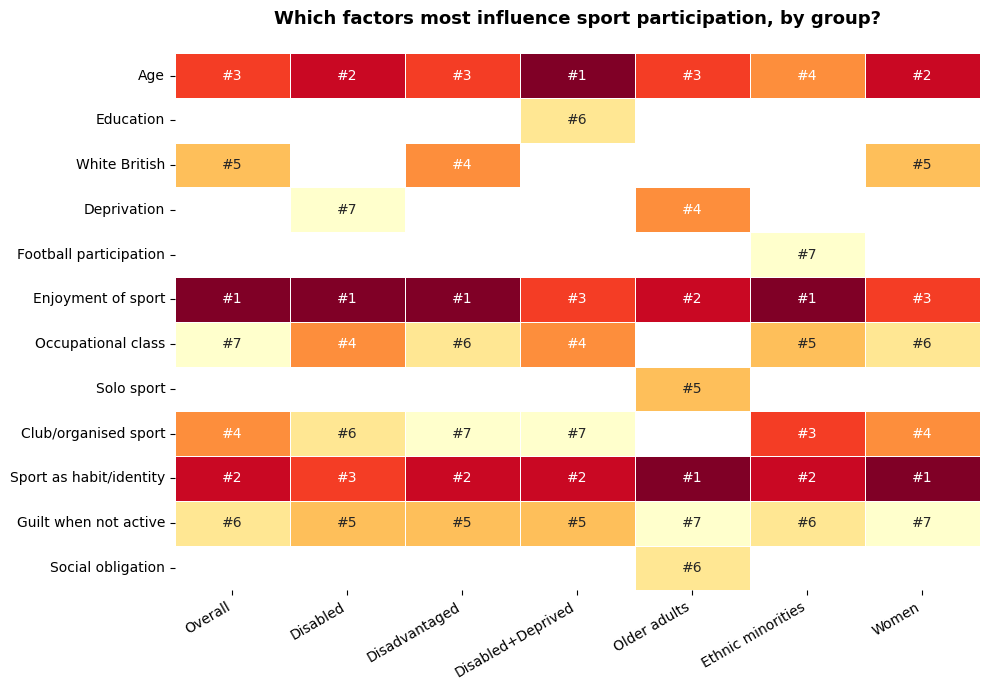

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

rename_index = {
    'Motiva_POP': 'Enjoyment of sport',
    'motivb_POP': 'Sport as habit/identity',
    'Age9': 'Age',
    'WHOWITHD_SPORTCOUNT_A01': 'Club/organised sport',
    'NSSEC5': 'Occupational class',
    'IMD10': 'Deprivation',
    'Eth7_1.0': 'White British',
    'Educ6': 'Education',
    'motivc_POP': 'Guilt when not active',
    'motivd_POP': 'Social obligation',
    'VolAny': 'Volunteering (any)',
    'VolFrqB_Pop': 'Volunteering frequency',
    'WHOWITHA_SPORTCOUNT_A01': 'Solo sport',
    'WHOWITHB_SPORTCOUNT_A01': 'Sport with household',
    'WHOWITHC_SPORTCOUNT_A01': 'Sport with friends',
    'MONTHS_12_FOOTBALL_F01': 'Football participation',
    'Eth7_4.0': 'Black ethnicity',
    'Disab3_1.0': 'Limiting disability',
}

rename_cols = {
    'overall': 'Overall',
    'disabled': 'Disabled',
    'disadvantaged': 'Disadvantaged',
    'disabled+deprived': 'Disabled+Deprived',
    'older': 'Older adults',
    'ethnic': 'Ethnic minorities',
    'women': 'Women',
}

comparison_plot = comparison.rename(index=rename_index, columns=rename_cols)
ranks = comparison_plot.rank(ascending=False, method='min', na_option='bottom').astype('Int64')
ranks_plot = ranks.where(comparison_plot.notna()).astype(float)

annot = '#' + ranks.astype(str)
annot[comparison_plot.isna()] = ''

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    ranks_plot,
    annot=annot,
    fmt='',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar=False
)
ax.set_title('Which factors most influence sport participation, by group?\n', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()